In [1]:
import os
import sys
import pathlib
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
e = 1     # on-site energy
h = 0.05  # hopping

ns = 200 # number of sites in a single lead

e_ = [e]*ns
h_ = [h]*ns
chain = np.column_stack((e_, h_))
chain[0,1] = h # coupling to QPC

In [14]:
# save chain parameters
np.savetxt('./chain.txt', chain, delimiter=' ')

In [3]:
# find the light cone
!qpc-prepare.py --tmax=800 --rtol=1E-5 --dt=0.01 --ringmax=5

Wellcome to lightcone constructor version 01.03.2023-14.44
Semiinfinite chain file:  chain.txt
Length of chain:  200
Relative significance treshold for forward lightcone boundary:  1e-05
Maximal size of ring:  5
Maximal time:  800.0
Time step:  0.01
Coupling to impurity:  0.05
The execution time : 35.05838632583618  sec


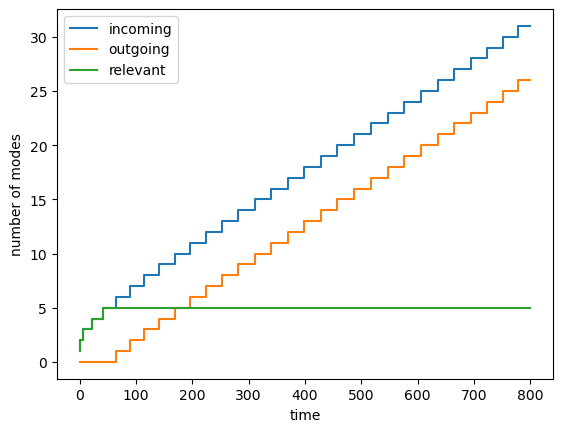

In [5]:
# vizualize the incoming and outgoing modes

import pathlib
intervals = []

try:
    with pathlib.Path("intervals.txt").open() as f:
        while True:
            l = [int(e) for e in next(f).split()] 
            intervals.append(l)
except StopIteration as e:
    pass

import matplotlib.pyplot as plt
dt = 0.01

x = []
y = []

for l in intervals:
    x.append(l[0]*dt)
    x.append(l[1]*dt)
    y.append(l[3])
    y.append(l[3])



plt.plot(x, y, label = 'incoming')


x = []
y = []

for l in intervals:
    x.append(l[0]*dt)
    x.append(l[1]*dt)
    y.append(l[2])
    y.append(l[2])
    
plt.plot(x, y, label = 'outgoing')

x = []
y = []

for l in intervals:
    x.append(l[0]*dt)
    x.append(l[1]*dt)
    y.append(l[3] - l[2])
    y.append(l[3] - l[2])
    
plt.plot(x, y, label = 'relevant')

plt.xlabel('time')
plt.ylabel('number of modes')
plt.legend()
plt.savefig('modes.png', dpi=300)

In [8]:
# numerically exact solution on initial time interval for checking the correctness

import numpy as np
import qpc.tools as tools
from qpc.tools import mv
from qpc import evolution

n_qua = 8
m_imp = 2
m_env = 10

m = tools.fermion_2lead_fermion_model(num_impurity_modes = m_imp, num_reservoir_modes = m_env, max_num_quanta = n_qua)

tmax = 100
dt = 0.01
t = np.arange(start = 0, stop = tmax, step = dt)
nt = t.size

nq = np.zeros(nt)

H_const = e * m.d_dag[1] @ m.d[1] - e * m.d_dag[0] @ m.d[0] \
    + h * m.d_dag[1] @ m.d_dag[0] + h *  m.d[0] @ m.d[1] \
    - h * m.d_dag[0] @ m.l[0]  - h * m.l_dag[0] @ m.d[0] \
    + h * m.r_dag[0] @ m.d[1] + h * m.d_dag[1] @ m.r[0] \
    - e * sum([m.l_dag[i] @ m.l[i] for i in range(m.m_env)]) \
    - h * sum([m.l_dag[i + 1] @ m.l[i] + m.l_dag[i] @ m.l[i + 1] for i in range(m.m_env - 1)]) \
    + e * sum([m.r_dag[i] @ m.r[i] for i in range(m.m_env)]) \
    + h * sum([m.r_dag[i + 1] @ m.r[i] + m.r_dag[i] @ m.r[i + 1] for i in range(m.m_env - 1)])

# buffer 
psi_buff = np.zeros(m.space.dimension, dtype = complex)

# how to apply Hamiltonian to psi-function at 
# midpoint time moment t_mid = (ti + 1/2) * dt
def apply_H(ti, psi_in, psi_out):
    mv(H_const, psi_in, psi_out, cout=1)

# the observable is the occupation of the right lead
oq =  sum([m.r_dag[i] @ m.r[i] for i in range(m.m_env)])

def eval_Oq(ti, psi):
    nq[ti] = np.vdot(psi, oq @ psi).real
    
psi_ini = np.zeros(m.space.dimension, dtype = complex)
psi_ini[0] = 1 

# buffers
psi = np.zeros(m.space.dimension, dtype = complex)
psi_mid = np.zeros(m.space.dimension, dtype = complex)
psi_mid_next = np.zeros(m.space.dimension, dtype = complex)

# Solve the Schrodinger equation via implicit midpoint method on time grid
evolution(0, nt, dt, apply_H, eval_Oq, psi_ini,  psi, psi_mid, psi_mid_next)

(array([1.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       shape=(600370,)),
 array([3.73598093e-06+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j, ...,
        0.00000000e+00+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j],
       shape=(600370,)),
 array([3.74065605e-06+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j, ...,
        0.00000000e+00+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j],
       shape=(600370,)),
 array([3.74065605e-06+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j, ...,
        0.00000000e+00+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j],
       shape=(600370,)))

Text(0, 0.5, 'occupation of the right lead')

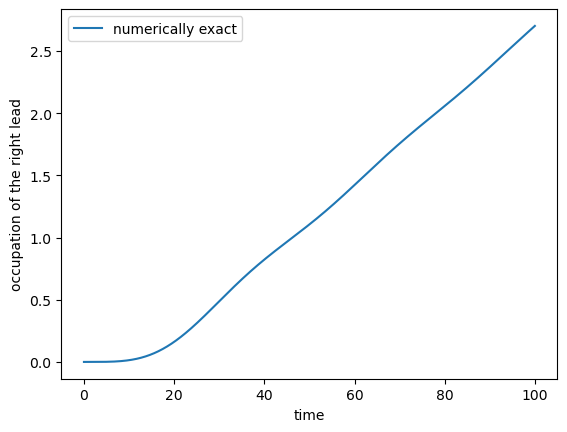

In [9]:
import matplotlib.pyplot as plt
plt.plot(t, nq, label = 'numerically exact')
plt.legend()
plt.xlabel('time')
plt.ylabel('occupation of the right lead')

In [ ]:
# now run the quantum jump simulation on longer time range
#!qpc-solve.py --maxcores=30 --cfrom=1 --cto=100 --csize=20 --fout=results1 --nquanta=7 --tmax=800

!qpc-solve.py --maxcores=8 --cfrom=1 --cto=1 --csize=8 --fout=results1 --nquanta=7 --tmax=800

Wellcome to lightcone impurity solver version 10.03.2023-11.51
Will read the lightcone info from the current directory
Will compute  8  trajectories
on max  8  CPU cores
Will save results into  results1
Will simulate up to time 800.0
Max number of coupled quanta:  7
on-site energy:  1
hopping:  0.05
Max number of coupled modes:  5
computing sparse matrices...
...done
submitting jobs to pool ...
running chunk  1 , of  8  trajectories


In [ ]:
# read results

import sys
import numpy as np
import os
import pathlib

folder = "results1"

with pathlib.Path(os.path.join(os.getcwd(), folder, "time.txt")).open() as f:
    tg = np.loadtxt(f)

ntg = tg.size
    
x = np.zeros(ntg, dtype = complex)
    
nsamples = 0
    
chunk_from = 1
# chunk_to = 100
chunk_to = 1

for i in range(chunk_from, chunk_to + 1):
    
    p = os.path.join(os.getcwd(), folder, "x_" + str(i) + ".txt")
    p = pathlib.Path(p)
    
    if not p.exists():
        continue
        
    with p.open() as f:
        xc = np.loadtxt(f)    
        nsamples += xc[0, 0]
        x[0 : xc.shape[0] - 1] += xc[1:, 0] + 1j * xc[1:, 1] 
    
x = x / nsamples    

In [ ]:
J = (x[1:] - x[:-1])/0.01

(-0.05, 0.05)

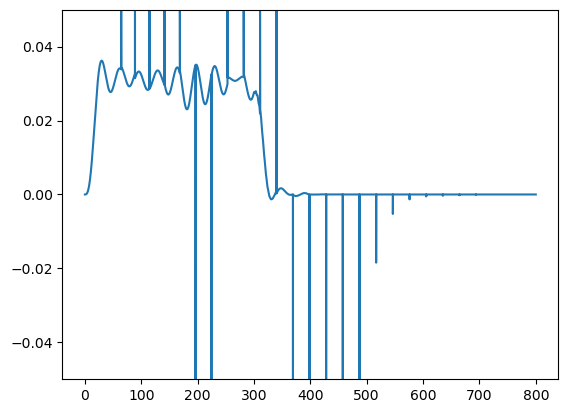

In [ ]:
plt.plot(tg[:-1], J.real, label = 'current')
plt.ylim(-0.05, 0.05)

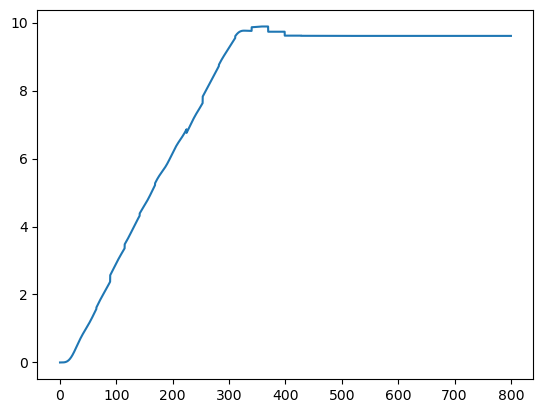

In [ ]:
import matplotlib.pyplot as plt
plt.plot(tg, x.real, label = 'jumps')

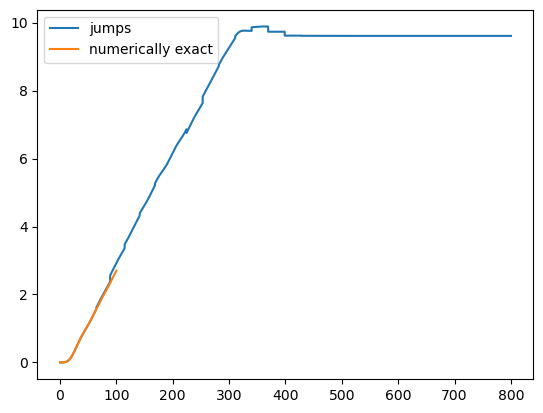

In [ ]:
import matplotlib.pyplot as plt
plt.plot(tg, x.real, label = 'jumps')
plt.plot(t, nq, label = 'numerically exact')
plt.legend()